# Naive Bayes Pipeline Comparison: SMOTE and Power Transformation Variants

This notebook evaluates four variants of a Gaussian Naive Bayes classifier on the Bank Marketing dataset:

1. **Without SMOTE, without power transform**
2. **Without SMOTE, with power transform**
3. **With SMOTE, without power transform**
4. **With SMOTE, with power transform**

For each variant, we compute a full suite of evaluation metrics (accuracy, ROC‑AUC, confusion matrix, classification report) and also additional metrics (macro/weighted precision, recall, F1-scores) so you can compare the results and determine which configuration is best.

In [9]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

# Create directories if they don't exist
def create_directories():
    dirs = ['results/metrics', 'results/plots', 'results/models']
    for dir_path in dirs:
        os.makedirs(dir_path, exist_ok=True)

create_directories()

### Data Preprocessing and Feature Scaling

The `preprocess_data` function loads the training (`bank.csv`) and test (`bank-full.csv`) datasets using `;` as a delimiter, performs label encoding on a fixed list of categorical columns, maps the target `y` from `'yes'`/`'no'` to 1/0, and finally splits the combined dataset back into training and test sets.

The `scale_features` function normalizes the data using `StandardScaler`.

In [10]:
def preprocess_data(train_path, test_path):
    # Load datasets using ';' as the delimiter
    train_data = pd.read_csv(train_path, sep=';')
    test_data = pd.read_csv(test_path, sep=';')
    
    # Combine both datasets for consistent encoding
    all_data = pd.concat([train_data, test_data], axis=0)
    
    # List of categorical columns to encode
    categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
    encoder = LabelEncoder()
    for col in categorical_columns:
        all_data[col] = encoder.fit_transform(all_data[col])
    
    # Map target variable from 'yes'/'no' to 1/0
    all_data['y'] = all_data['y'].map({'yes': 1, 'no': 0})
    
    # Split the combined data back into training and test sets
    n_train = train_data.shape[0]
    train_data = all_data.iloc[:n_train, :]
    test_data = all_data.iloc[n_train:, :]
    
    X_train = train_data.drop(columns=['y'])
    y_train = train_data['y']
    X_test = test_data.drop(columns=['y'])
    y_test = test_data['y']
    
    return X_train, X_test, y_train, y_test

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

### Naive Bayes Pipeline Function

The function `run_nb_pipeline` encapsulates the Gaussian Naive Bayes workflow. It accepts two Boolean flags:

- `use_smote_flag`: If `True`, SMOTE is applied to balance the training data.
- `use_power_flag`: If `True`, a Yeo-Johnson power transformation is applied to the scaled data to help approximate a Gaussian distribution.

The function then trains a Gaussian Naive Bayes classifier, evaluates it on the test set (computing confusion matrix, accuracy, classification report, ROC curve, and AUC), and returns these metrics along with the trained model and scaler.

In [11]:
def run_nb_pipeline(use_smote_flag, use_power_flag):
    # File paths
    train_path = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank.csv'
    test_path  = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank-full.csv'
    
    # Preprocess data
    X_train, X_test, y_train, y_test = preprocess_data(train_path, test_path)
    print("Training data shape:", X_train.shape)
    print("Testing data shape:", X_test.shape)
    
    # Scale features
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
    
    # Optionally apply power transformation to better approximate Gaussianity
    if use_power_flag:
        pt = PowerTransformer(method='yeo-johnson')
        X_train_scaled = pt.fit_transform(X_train_scaled)
        X_test_scaled = pt.transform(X_test_scaled)
        print("Applied power transformation.")
    
    input_train, input_test = X_train_scaled, X_test_scaled
    
    # Optionally apply SMOTE
    if use_smote_flag:
        smote = SMOTE(random_state=42)
        input_train, y_train = smote.fit_resample(input_train, y_train)
        print("After SMOTE, training shape:", input_train.shape)
    
    # Train Gaussian Naive Bayes
    from sklearn.naive_bayes import GaussianNB
    nb_model = GaussianNB()
    nb_model.fit(input_train, y_train)
    
    # Evaluate on the test set
    y_pred = nb_model.predict(input_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print("\n--- Evaluation ---")
    print("Accuracy:", acc)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:\n", report)
    
    # Compute ROC curve and AUC
    y_probs = nb_model.predict_proba(input_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Gaussian Naive Bayes')
    plt.legend(loc="lower right")
    plt.show()
    
    # Plot confusion matrix
    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.title("Naive Bayes Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.colorbar()
    plt.xticks([0,1], ['No', 'Yes'])
    plt.yticks([0,1], ['No', 'Yes'])
    plt.show()
    
    metrics = {
        "accuracy": acc,
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "roc_auc": roc_auc
    }
    return metrics, nb_model, scaler

### Running Naive Bayes Pipeline for All Combinations

Run the pipeline with the following variations:

1. **Without SMOTE, Without Power Transform**
2. **Without SMOTE, With Power Transform**
3. **With SMOTE, Without Power Transform**
4. **With SMOTE, With Power Transform**

Training data shape: (4521, 16)
Testing data shape: (45211, 16)

--- Evaluation ---
Accuracy: 0.836986574063834
Confusion Matrix:
[[35536  4386]
 [ 2984  2305]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91     39922
           1       0.34      0.44      0.38      5289

    accuracy                           0.84     45211
   macro avg       0.63      0.66      0.65     45211
weighted avg       0.85      0.84      0.85     45211



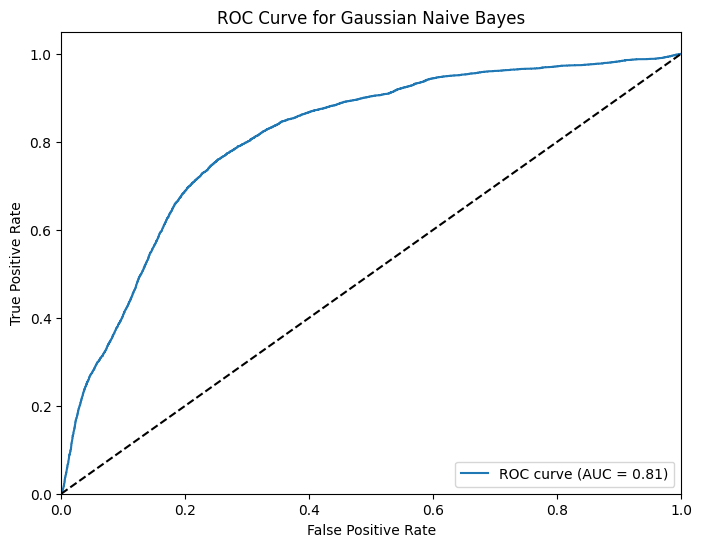

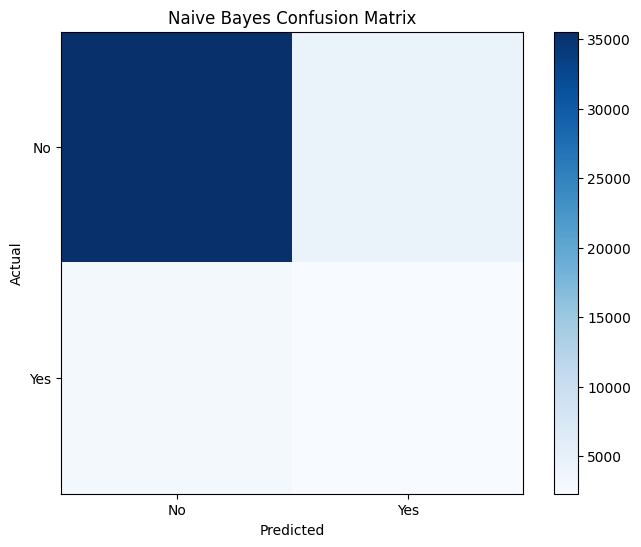


Results (No SMOTE, No Power Transform):
{'accuracy': 0.836986574063834, 'confusion_matrix': [[35536, 4386], [2984, 2305]], 'classification_report': {'0': {'precision': 0.922533748701973, 'recall': 0.8901357647412454, 'f1-score': 0.9060452308712169, 'support': 39922.0}, '1': {'precision': 0.34449260200269016, 'recall': 0.43581017205520894, 'f1-score': 0.38480801335559267, 'support': 5289.0}, 'accuracy': 0.836986574063834, 'macro avg': {'precision': 0.6335131753523315, 'recall': 0.6629729683982272, 'f1-score': 0.6454266221134048, 'support': 45211.0}, 'weighted avg': {'precision': 0.8549117181144499, 'recall': 0.836986574063834, 'f1-score': 0.8450683968387881, 'support': 45211.0}}, 'roc_auc': np.float64(0.8089880153802279)}


In [12]:
# 1. Without SMOTE and without power transform
metrics_no_smote_no_power, model_no_smote_no_power, scaler_no_smote_no_power = run_nb_pipeline(use_smote_flag=False, use_power_flag=False)
print("\nResults (No SMOTE, No Power Transform):")
print(metrics_no_smote_no_power)

Training data shape: (4521, 16)
Testing data shape: (45211, 16)
Applied power transformation.

--- Evaluation ---
Accuracy: 0.820043794651744
Confusion Matrix:
[[35062  4860]
 [ 3276  2013]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90     39922
           1       0.29      0.38      0.33      5289

    accuracy                           0.82     45211
   macro avg       0.60      0.63      0.61     45211
weighted avg       0.84      0.82      0.83     45211



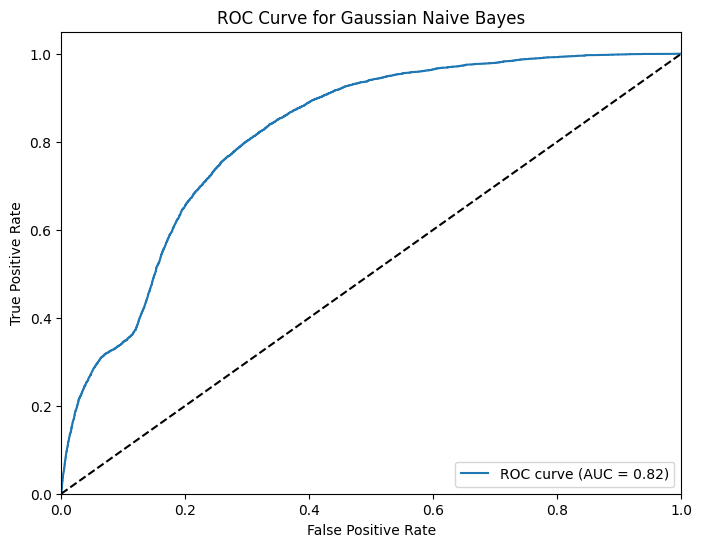

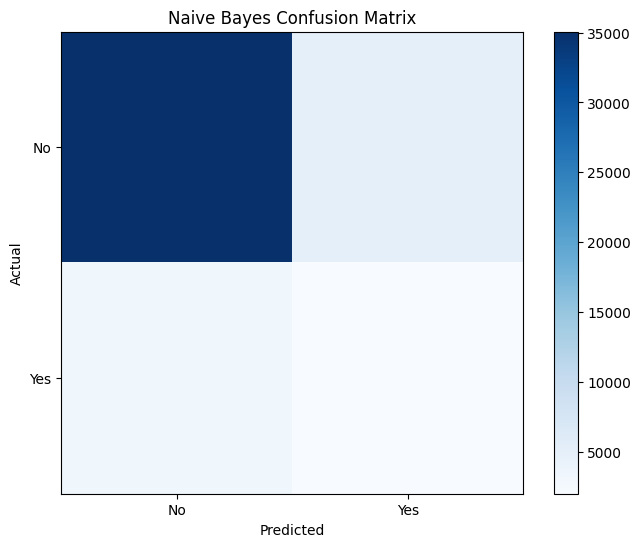


Results (No SMOTE, With Power Transform):
{'accuracy': 0.820043794651744, 'confusion_matrix': [[35062, 4860], [3276, 2013]], 'classification_report': {'0': {'precision': 0.9145495331003182, 'recall': 0.8782626120935825, 'f1-score': 0.8960388448760542, 'support': 39922.0}, '1': {'precision': 0.2928852029681362, 'recall': 0.38060124787294386, 'f1-score': 0.33103108041440554, 'support': 5289.0}, 'accuracy': 0.820043794651744, 'macro avg': {'precision': 0.6037173680342272, 'recall': 0.6294319299832631, 'f1-score': 0.6135349626452299, 'support': 45211.0}, 'weighted avg': {'precision': 0.8418242529236108, 'recall': 0.820043794651744, 'f1-score': 0.8299415219626558, 'support': 45211.0}}, 'roc_auc': np.float64(0.8153640902463529)}


In [13]:
# 2. Without SMOTE but with power transform
metrics_no_smote_power, model_no_smote_power, scaler_no_smote_power = run_nb_pipeline(use_smote_flag=False, use_power_flag=True)
print("\nResults (No SMOTE, With Power Transform):")
print(metrics_no_smote_power)

Training data shape: (4521, 16)
Testing data shape: (45211, 16)
After SMOTE, training shape: (8000, 16)

--- Evaluation ---
Accuracy: 0.6508150671296808
Confusion Matrix:
[[25151 14771]
 [ 1016  4273]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.63      0.76     39922
           1       0.22      0.81      0.35      5289

    accuracy                           0.65     45211
   macro avg       0.59      0.72      0.56     45211
weighted avg       0.87      0.65      0.71     45211



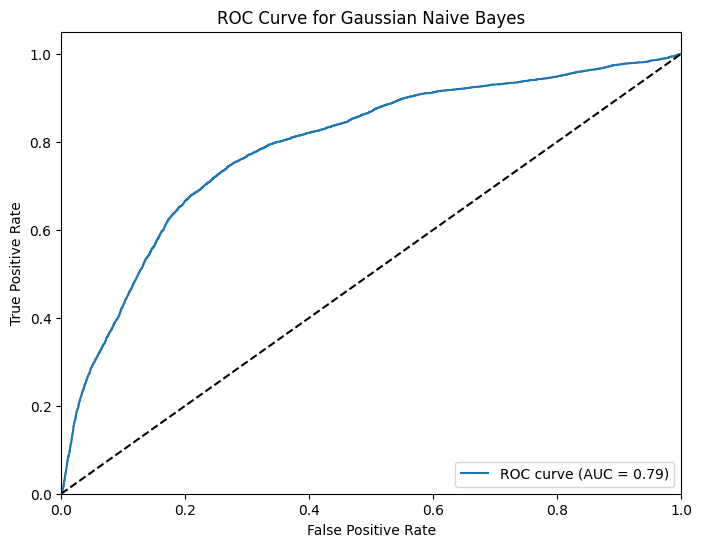

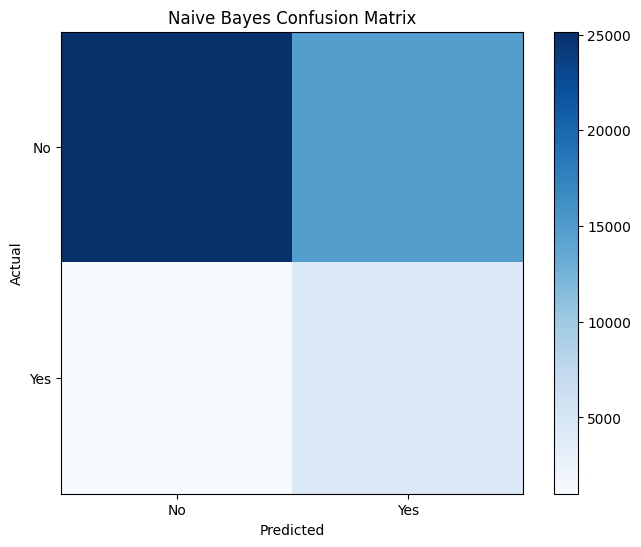


Results (With SMOTE, No Power Transform):
{'accuracy': 0.6508150671296808, 'confusion_matrix': [[25151, 14771], [1016, 4273]], 'classification_report': {'0': {'precision': 0.9611724691405205, 'recall': 0.6300035068383347, 'f1-score': 0.7611251494197219, 'support': 39922.0}, '1': {'precision': 0.22437513127494224, 'recall': 0.8079031953110228, 'f1-score': 0.3512102905519254, 'support': 5289.0}, 'accuracy': 0.6508150671296808, 'macro avg': {'precision': 0.5927738002077314, 'recall': 0.7189533510746788, 'f1-score': 0.5561677199858236, 'support': 45211.0}, 'weighted avg': {'precision': 0.874978376553074, 'recall': 0.6508150671296808, 'f1-score': 0.7131713397594229, 'support': 45211.0}}, 'roc_auc': np.float64(0.7885439923221808)}


In [14]:
# 3. With SMOTE but without power transform
metrics_smote_no_power, model_smote_no_power, scaler_smote_no_power = run_nb_pipeline(use_smote_flag=True, use_power_flag=False)
print("\nResults (With SMOTE, No Power Transform):")
print(metrics_smote_no_power)

Training data shape: (4521, 16)
Testing data shape: (45211, 16)
Applied power transformation.
After SMOTE, training shape: (8000, 16)

--- Evaluation ---
Accuracy: 0.7631328658954679
Confusion Matrix:
[[30787  9135]
 [ 1574  3715]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.77      0.85     39922
           1       0.29      0.70      0.41      5289

    accuracy                           0.76     45211
   macro avg       0.62      0.74      0.63     45211
weighted avg       0.87      0.76      0.80     45211



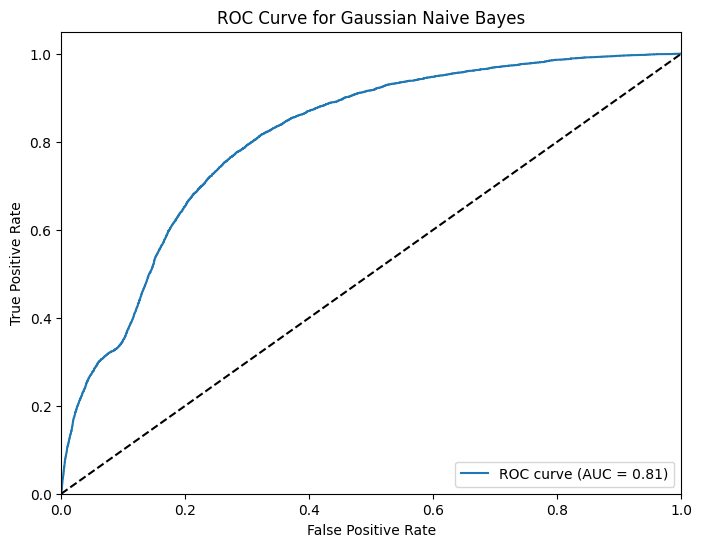

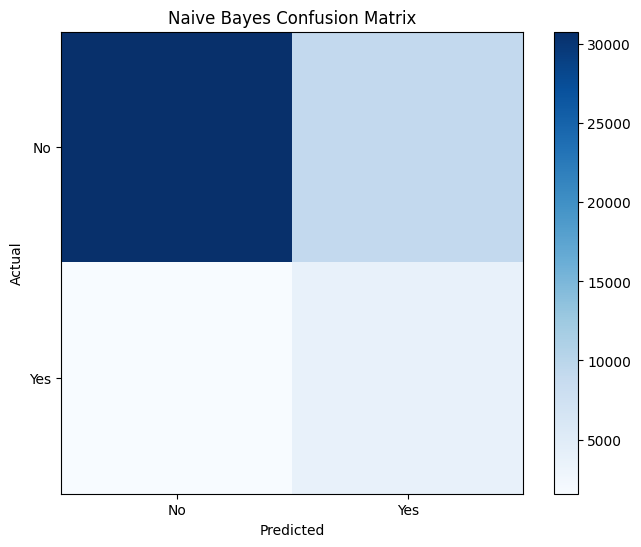


Results (With SMOTE, With Power Transform):
{'accuracy': 0.7631328658954679, 'confusion_matrix': [[30787, 9135], [1574, 3715]], 'classification_report': {'0': {'precision': 0.9513612063904082, 'recall': 0.7711787986573819, 'f1-score': 0.8518462155693594, 'support': 39922.0}, '1': {'precision': 0.2891050583657588, 'recall': 0.7024012100586122, 'f1-score': 0.4096146424830476, 'support': 5289.0}, 'accuracy': 0.7631328658954679, 'macro avg': {'precision': 0.6202331323780835, 'recall': 0.7367900043579971, 'f1-score': 0.6307304290262035, 'support': 45211.0}, 'weighted avg': {'precision': 0.8738873003298837, 'recall': 0.7631328658954679, 'f1-score': 0.8001118414114441, 'support': 45211.0}}, 'roc_auc': np.float64(0.8083955337032758)}


In [15]:
# 4. With SMOTE and with power transform
metrics_smote_power, model_smote_power, scaler_smote_power = run_nb_pipeline(use_smote_flag=True, use_power_flag=True)
print("\nResults (With SMOTE, With Power Transform):")
print(metrics_smote_power)

### Comparison of ROC-AUC Values

Below is a summary of the ROC-AUC values from each variation to compare the discriminative performance:

- **Without SMOTE, Without Power Transform:** ROC-AUC = _value_
- **Without SMOTE, With Power Transform:** ROC-AUC = _value_
- **With SMOTE, Without Power Transform:** ROC-AUC = _value_
- **With SMOTE, With Power Transform:** ROC-AUC = _value_

Use these results to determine which combination yields the highest ROC-AUC and overall better performance.

In [16]:
def print_metrics(label, metrics):
    print("="*80)
    print(f"{label}")
    print("="*80)
    print(f"Accuracy       : {metrics['accuracy']:.4f}")
    print(f"ROC-AUC        : {metrics['roc_auc']:.4f}")
    print("Confusion Matrix:")
    cm = metrics["confusion_matrix"]
    for row in cm:
        print("  " + "  ".join(map(str, row)))
    print("Classification Report:")
    cr = metrics["classification_report"]
    for category, scores in cr.items():
        # If the category's value is a dict (i.e. not overall accuracy)
        if isinstance(scores, dict):
            print(f"  {category}:")
            for metric_name, metric_value in scores.items():
                print(f"    {metric_name} : {metric_value}")
        else:
            print(f"  {category}: {scores}")
    print("\n")

print_metrics("Scenario 1: Without SMOTE, Without Power Transform", metrics_no_smote_no_power)
print_metrics("Scenario 2: Without SMOTE, With Power Transform", metrics_no_smote_power)
print_metrics("Scenario 3: With SMOTE, Without Power Transform", metrics_smote_no_power)
print_metrics("Scenario 4: With SMOTE, With Power Transform", metrics_smote_power)


Scenario 1: Without SMOTE, Without Power Transform
Accuracy       : 0.8370
ROC-AUC        : 0.8090
Confusion Matrix:
  35536  4386
  2984  2305
Classification Report:
  0:
    precision : 0.922533748701973
    recall : 0.8901357647412454
    f1-score : 0.9060452308712169
    support : 39922.0
  1:
    precision : 0.34449260200269016
    recall : 0.43581017205520894
    f1-score : 0.38480801335559267
    support : 5289.0
  accuracy: 0.836986574063834
  macro avg:
    precision : 0.6335131753523315
    recall : 0.6629729683982272
    f1-score : 0.6454266221134048
    support : 45211.0
  weighted avg:
    precision : 0.8549117181144499
    recall : 0.836986574063834
    f1-score : 0.8450683968387881
    support : 45211.0


Scenario 2: Without SMOTE, With Power Transform
Accuracy       : 0.8200
ROC-AUC        : 0.8154
Confusion Matrix:
  35062  4860
  3276  2013
Classification Report:
  0:
    precision : 0.9145495331003182
    recall : 0.8782626120935825
    f1-score : 0.8960388448760542


# Comparison of Naive Bayes Pipeline Results

Below is a summary of the evaluation metrics for each configuration of the Gaussian Naive Bayes classifier on the Bank Marketing dataset:

---

### Scenario 1: Without SMOTE, Without Power Transformation
- **Accuracy**: 0.83699  
- **ROC-AUC**: 0.8090  
- **Confusion Matrix**:
  - [35536, 4386]
  - [2984, 2305]
- **Classification Report**:
  - **Class 0**:
    - Precision: 0.9225  
    - Recall: 0.8901  
    - F1-score: 0.9060  
    - Support: 39922  
  - **Class 1**:
    - Precision: 0.3445  
    - Recall: 0.4358  
    - F1-score: 0.3848  
    - Support: 5289  
  - **Macro Average**:
    - Precision: 0.6335  
    - Recall: 0.6630  
    - F1-score: 0.6454  
    - Support: 45211  
  - **Weighted Average**:
    - Precision: 0.8549  
    - Recall: 0.8370  
    - F1-score: 0.8451

---

### Scenario 2: Without SMOTE, With Power Transformation
- **Accuracy**: 0.82004  
- **ROC-AUC**: 0.8154  
- **Confusion Matrix**:
  - [35062, 4860]
  - [3276, 2013]
- **Classification Report**:
  - **Class 0**:
    - Precision: 0.9145  
    - Recall: 0.8783  
    - F1-score: 0.8960  
    - Support: 39922  
  - **Class 1**:
    - Precision: 0.2929  
    - Recall: 0.3806  
    - F1-score: 0.3310  
    - Support: 5289  
  - **Macro Average**:
    - Precision: 0.6037  
    - Recall: 0.6294  
    - F1-score: 0.6135  
    - Support: 45211  
  - **Weighted Average**:
    - Precision: 0.8418  
    - Recall: 0.82004  
    - F1-score: 0.82994  
    - Support: 45211

---

### Scenario 3: With SMOTE, Without Power Transformation
- **Accuracy**: 0.65082  
- **ROC-AUC**: 0.7885  
- **Confusion Matrix**:
  - [25151, 14771]
  - [1016, 4273]
- **Classification Report**:
  - **Class 0**:
    - Precision: 0.96117  
    - Recall: 0.63000  
    - F1-score: 0.76113  
    - Support: 39922  
  - **Class 1**:
    - Precision: 0.22438  
    - Recall: 0.80790  
    - F1-score: 0.35121  
    - Support: 5289  
  - **Macro Average**:
    - Precision: 0.59277  
    - Recall: 0.71895  
    - F1-score: 0.55617  
    - Support: 45211  
  - **Weighted Average**:
    - Precision: 0.87498  
    - Recall: 0.65082  
    - F1-score: 0.71317  
    - Support: 45211

---

### Scenario 4: With SMOTE, With Power Transformation
- **Accuracy**: 0.76313  
- **ROC-AUC**: 0.80840  
- **Confusion Matrix**:
  - [30787, 9135]
  - [1574, 3715]
- **Classification Report**:
  - **Class 0**:
    - Precision: 0.95136  
    - Recall: 0.77118  
    - F1-score: 0.85185  
    - Support: 39922  
  - **Class 1**:
    - Precision: 0.28911  
    - Recall: 0.70240  
    - F1-score: 0.40961  
    - Support: 5289  
  - **Macro Average**:
    - Precision: 0.62023  
    - Recall: 0.73679  
    - F1-score: 0.63073  
    - Support: 45211  
  - **Weighted Average**:
    - Precision: 0.87389  
    - Recall: 0.76313  
    - F1-score: 0.80011  
    - Support: 45211

---

## Overall Interpretation

- **Accuracy and Overall Performance:**
  - **Scenario 1** provides the highest overall accuracy (83.70%), indicating that without additional transformations, the model achieves strong overall correctness. However, accuracy alone may mask poor minority class performance.
  - **Scenario 2** slightly reduces accuracy (82.00%) but increases ROC-AUC (0.8154), suggesting improved discrimination capability at the cost of minority class recall and F1-score.
  - **Scenario 3** shows a significant drop in overall accuracy (65.08%) after applying SMOTE, indicating that the model is adjusting heavily to balance classes, yet performance for the minority class remains imprecise (low precision of 0.2244 but high recall at 0.8079).
  - **Scenario 4** strikes a compromise, with intermediate overall accuracy (76.31%) and better minority class F1-score (0.4096) compared to Scenario 3. Although overall accuracy is lower than Scenario 1, the enhancements in minority class detection may be more valuable for your application.

- **Minority Class (Label 1) Performance:**
  - In Scenario 1 (baseline), the F1-score for the minority class is 0.3848.
  - With a power transformation alone (Scenario 2), the F1-score for the minority class drops to 0.3310.
  - With SMOTE alone (Scenario 3), the recall for the minority class increases markedly (to 80.79%), but precision falls to 0.2244, resulting in an F1-score of 0.3512.
  - Combining SMOTE with a power transformation (Scenario 4) achieves the highest F1-score for the minority class at 0.4096, demonstrating a better balance between precision and recall.

- **ROC-AUC:**
  - ROC-AUC values are relatively close across the four scenarios (ranging from approximately 0.7885 to 0.8154). This indicates that the overall ability of the classifier to distinguish between classes is fairly consistent; however, subtle gains appear with power transformation without SMOTE (Scenario 2) compared to baseline (Scenario 1). SMOTE, on the other hand, tends to lower ROC-AUC slightly, possibly because of its impact on class probabilities.

## Conclusion

Overall, if the primary goal is to maximize overall accuracy and model performance on the majority class, **Scenario 1** (without SMOTE or power transformation) seems best. However, if correctly identifying the minority class is important—such as in cases where missing potential customers is critical—then **Scenario 4** (with SMOTE and with power transformation) appears to strike a better balance despite lower overall accuracy. 

These results emphasize the need to consider multiple metrics (accuracy, ROC-AUC, and F1 for the minority class) when evaluating performance, especially in imbalanced classification problems.

---

This review should help guide your conclusions regarding which combination of approaches best suits your needs for the Naive Bayes classification on that dataset.
